# 10 — Resultados y gráficas

Este notebook reúne los resultados de test del Baseline MLP y del VLA propuesto. Presenta tablas y gráficas sencillas de precisión y eficiencia para facilitar su incorporación a la memoria.

RT-2 se incluye únicamente como referencia del estado del arte: su escala, datos y protocolo son diferentes, por lo que no se realiza una comparación experimental numérica directa.

## 1. Configuración e imports

Se definen las rutas de entrada y salida. Las figuras se guardan en una carpeta específica para mantener los resultados organizados.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'src').exists() else NOTEBOOK_DIR
if not (ROOT_DIR / 'src').exists():
    raise FileNotFoundError('No se ha encontrado la carpeta src del proyecto.')
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.project_config import PROJECT_DIR, experiment_dirs

PROJECT_DIR = Path(PROJECT_DIR)
INPUT_PATH = PROJECT_DIR / 'results' / 'evaluacion_final' / 'evaluacion_test.json'
OUTPUT_DIRS = experiment_dirs('resultados_finales')
RESULTS_DIR = OUTPUT_DIRS['results']
FIGURES_DIR = OUTPUT_DIRS['figures']

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C78A8', '#F58518']
print(f'Resultados de entrada: {INPUT_PATH}')
print(f'Figuras de salida: {FIGURES_DIR}')

Resultados de entrada: C:\TFM_Codigo\TFM-VLA\results\evaluacion_final\evaluacion_test.json
Figuras de salida: C:\TFM_Codigo\TFM-VLA\figures\resultados_finales


## 2. Carga de resultados

Se leen los resultados generados en el notebook 09. Este archivo contiene las métricas de test y los datos de eficiencia de ambos modelos.

In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No existe {INPUT_PATH}. Ejecuta antes 09_evaluacion.ipynb.')

with INPUT_PATH.open(encoding='utf-8') as archivo:
    resultados = json.load(archivo)

comparison = pd.DataFrame(resultados['comparison']).set_index('modelo')
# Se usa una etiqueta descriptiva en las tablas y gráficas finales.
comparison = comparison.rename(index={'VLA referencia': 'VLA propuesto'})
vla_metrics = resultados['vla']['test_metrics']
baseline_metrics = resultados['baseline']['test_metrics']

print(f"Muestras evaluadas: {resultados['test_samples']:,}")
display(comparison.round(4))

Muestras evaluadas: 23,826


,MAE,RMSE,coseno_xyz,terminate_accuracy,terminate_F1,gripper_accuracy,gripper_F1,parámetros_totales,parámetros_entrenables,ms_por_muestra,desviación_ms,tiempo_entrenamiento_s,tiempo_medio_época_s
modelo,,,,,,,,,,,,,
VLA propuesto,0.0346,0.0516,0.0572,0.9600,0.0498,0.8312,0.7884,1352072,1352072,0.0952,0.0148,1252.6319,417.5440
Baseline MLP,0.0333,0.0487,0.3186,0.9699,0.2077,0.8899,0.8681,920328,920328,0.0234,0.0031,642.2723,32.1136


## 3. Tabla de comparación experimental

La tabla resume las medidas principales. Los errores bajos son preferibles para MAE y RMSE; los valores altos son preferibles para la similitud del coseno y los F1.

In [3]:
summary_columns = [
    'MAE', 'RMSE', 'coseno_xyz', 'terminate_F1', 'gripper_F1',
    'parámetros_entrenables', 'ms_por_muestra', 'tiempo_entrenamiento_s',
]
summary_table = comparison[summary_columns].copy()
summary_table.columns = [
    'MAE', 'RMSE', 'Coseno xyz', 'F1 terminate', 'F1 pinza',
    'Parámetros entrenables', 'ms por muestra', 'Tiempo entrenamiento (s)',
]
display(summary_table.round(4))

summary_path = RESULTS_DIR / 'tabla_comparacion_experimental.csv'
summary_table.to_csv(summary_path)
print(f'Tabla guardada en: {summary_path}')

,MAE,RMSE,Coseno xyz,F1 terminate,F1 pinza,Parámetros entrenables,ms por muestra,Tiempo entrenamiento (s)
modelo,,,,,,,,
VLA propuesto,0.0346,0.0516,0.0572,0.0498,0.7884,1352072,0.0952,1252.6319
Baseline MLP,0.0333,0.0487,0.3186,0.2077,0.8681,920328,0.0234,642.2723


Tabla guardada en: C:\TFM_Codigo\TFM-VLA\results\resultados_finales\tabla_comparacion_experimental.csv


## 4. Gráficas de precisión

Las primeras gráficas comparan el error global, las métricas F1 de las salidas binarias y el error de cada componente continua de la acción.

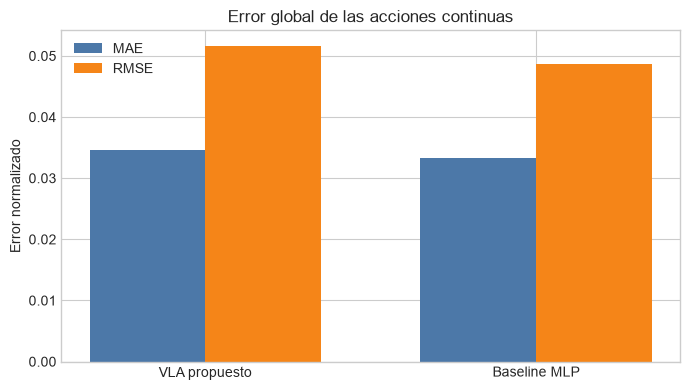

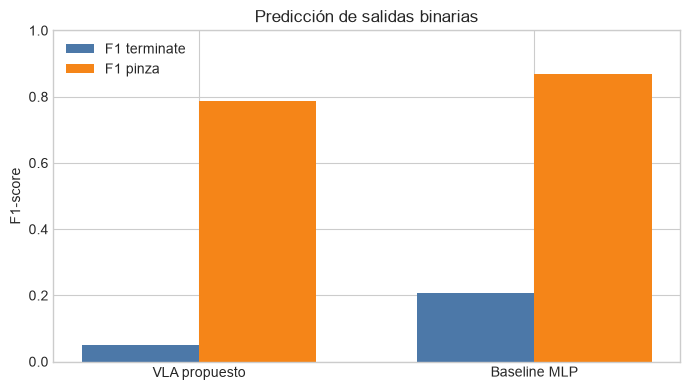

In [4]:
model_names = comparison.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, comparison['MAE'], width, label='MAE', color=COLORS[0])
ax.bar(x + width / 2, comparison['RMSE'], width, label='RMSE', color=COLORS[1])
ax.set_xticks(x, model_names)
ax.set_ylabel('Error normalizado')
ax.set_title('Error global de las acciones continuas')
ax.legend()
fig.tight_layout()
error_path = FIGURES_DIR / 'error_global.png'
fig.savefig(error_path, dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, comparison['terminate_F1'], width, label='F1 terminate', color=COLORS[0])
ax.bar(x + width / 2, comparison['gripper_F1'], width, label='F1 pinza', color=COLORS[1])
ax.set_xticks(x, model_names)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-score')
ax.set_title('Predicción de salidas binarias')
ax.legend()
fig.tight_layout()
f1_path = FIGURES_DIR / 'f1_salidas_binarias.png'
fig.savefig(f1_path, dpi=150)
plt.show()

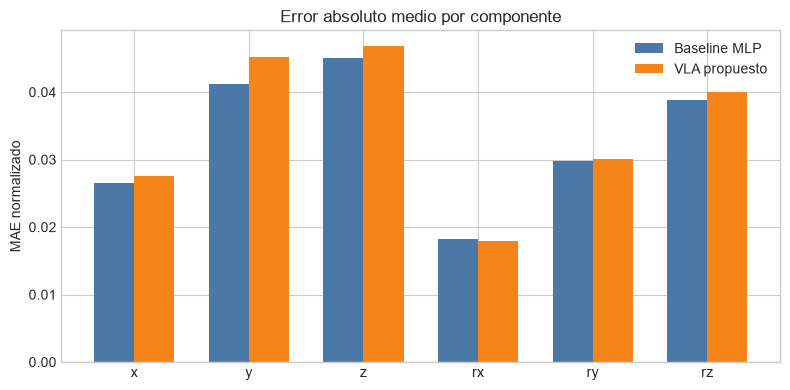

In [5]:
components = ['x', 'y', 'z', 'rx', 'ry', 'rz']
vla_mae = [vla_metrics['continuous_normalized']['mae_by_component'][component] for component in components]
baseline_mae = [baseline_metrics['continuous_normalized']['mae_by_component'][component] for component in components]

fig, ax = plt.subplots(figsize=(8, 4))
component_x = np.arange(len(components))
ax.bar(component_x - width / 2, baseline_mae, width, label='Baseline MLP', color=COLORS[0])
ax.bar(component_x + width / 2, vla_mae, width, label='VLA propuesto', color=COLORS[1])
ax.set_xticks(component_x, components)
ax.set_ylabel('MAE normalizado')
ax.set_title('Error absoluto medio por componente')
ax.legend()
fig.tight_layout()
component_path = FIGURES_DIR / 'mae_por_componente.png'
fig.savefig(component_path, dpi=150)
plt.show()

## 5. Gráficas de eficiencia

Estas gráficas muestran el tamaño de los modelos y el coste temporal medido sobre embeddings cacheados. Las dos configuraciones se comparan bajo las mismas condiciones.

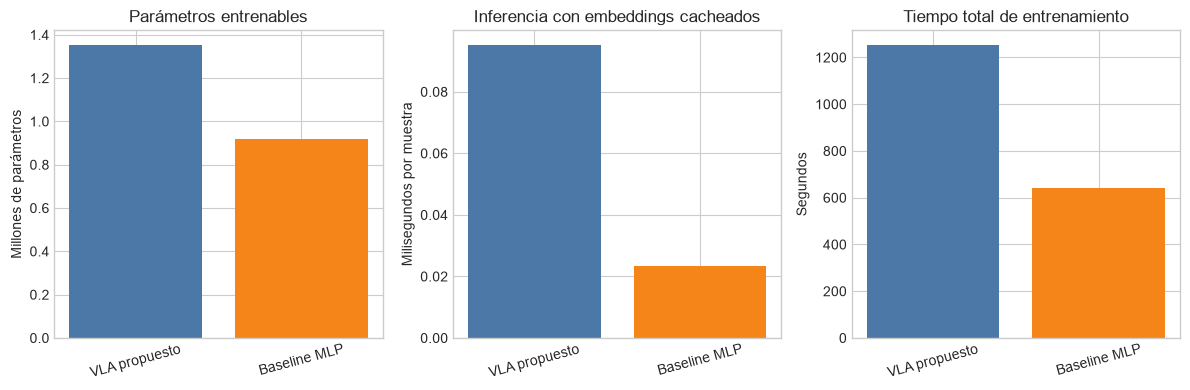

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Se muestran los parámetros en millones para facilitar la lectura.
axes[0].bar(model_names, comparison['parámetros_entrenables'] / 1e6, color=COLORS)
axes[0].set_ylabel('Millones de parámetros')
axes[0].set_title('Parámetros entrenables')

axes[1].bar(model_names, comparison['ms_por_muestra'], color=COLORS)
axes[1].set_ylabel('Milisegundos por muestra')
axes[1].set_title('Inferencia con embeddings cacheados')

axes[2].bar(model_names, comparison['tiempo_entrenamiento_s'], color=COLORS)
axes[2].set_ylabel('Segundos')
axes[2].set_title('Tiempo total de entrenamiento')

for axis in axes:
    axis.tick_params(axis='x', rotation=15)
fig.tight_layout()
efficiency_path = FIGURES_DIR / 'eficiencia_computacional.png'
fig.savefig(efficiency_path, dpi=150)
plt.show()

## 6. RT-2 como referencia del estado del arte

RT-2 aporta el contexto conceptual del trabajo. La siguiente tabla describe diferencias de arquitectura y escala, pero no enfrenta sus resultados publicados con las métricas de este proyecto.

In [7]:
rt2_reference = pd.DataFrame([
    {
        'Aspecto': 'Arquitectura',
        'Baseline MLP': 'Embeddings CLIP concatenados y red MLP',
        'VLA propuesto': 'CLIP congelado, Transformer ligero y decodificador de acciones',
        'RT-2': 'Modelo visión-lenguaje de gran escala adaptado a acciones robóticas',
    },
    {
        'Aspecto': 'Datos y escala',
        'Baseline MLP': 'Demostraciones TACO Play usadas en este proyecto',
        'VLA propuesto': 'Demostraciones TACO Play usadas en este proyecto',
        'RT-2': 'Datos web y demostraciones robóticas a una escala superior',
    },
    {
        'Aspecto': 'Evaluación',
        'Baseline MLP': 'Predicción offline de acciones en test',
        'VLA propuesto': 'Predicción offline de acciones en test',
        'RT-2': 'Tareas robóticas y protocolo experimental propio',
    },
    {
        'Aspecto': 'Papel en este trabajo',
        'Baseline MLP': 'Referencia experimental directa',
        'VLA propuesto': 'Propuesta evaluada',
        'RT-2': 'Referencia conceptual del estado del arte',
    },
]).set_index('Aspecto')
display(rt2_reference)

rt2_path = RESULTS_DIR / 'referencia_cualitativa_rt2.csv'
rt2_reference.to_csv(rt2_path)
print(f'Tabla guardada en: {rt2_path}')

,Baseline MLP,VLA propuesto,RT-2
Aspecto,,,
Arquitectura,Embeddings CLIP concatenados y red MLP,"CLIP congelado, Transformer ligero y decodific...",Modelo visión-lenguaje de gran escala adaptado...
Datos y escala,Demostraciones TACO Play usadas en este proyecto,Demostraciones TACO Play usadas en este proyecto,Datos web y demostraciones robóticas a una esc...
Evaluación,Predicción offline de acciones en test,Predicción offline de acciones en test,Tareas robóticas y protocolo experimental propio
Papel en este trabajo,Referencia experimental directa,Propuesta evaluada,Referencia conceptual del estado del arte


Tabla guardada en: C:\TFM_Codigo\TFM-VLA\results\resultados_finales\referencia_cualitativa_rt2.csv


## 7. Resumen final

La comparación experimental se limita a los dos modelos evaluados con las mismas muestras de test. Las figuras y tablas guardadas resumen por separado precisión y eficiencia; RT-2 se utiliza para contextualizar la propuesta sin inferir una equivalencia cuantitativa.

In [8]:
figures = [error_path, f1_path, component_path, efficiency_path]
print('Resultados preparados para la memoria:')
for figure in figures:
    print(f' - {figure.name}')
print(f' - {summary_path.name}')
print(f' - {rt2_path.name}')

Resultados preparados para la memoria:
 - error_global.png
 - f1_salidas_binarias.png
 - mae_por_componente.png
 - eficiencia_computacional.png
 - tabla_comparacion_experimental.csv
 - referencia_cualitativa_rt2.csv
